# Resolution Calibration: calibrate → pin → fit

A measured resonance dip is broadened by several separate effects: the **instrument
resolution** (a beamline property), **Doppler** broadening (sample temperature),
**background/normalization**, and **self-shielding/scattering** in black resonances.
On one spectrum these trade off, so the instrument resolution must be characterized
on a *known* standard and then held fixed when fitting unknown samples.

This notebook shows the three resolution models and the **calibrate → pin → fit**
workflow. See also the [Instrument Resolution & Calibration](../../docs/guide/src/resolution-calibration.md) guide.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nereids

plt.rcParams['figure.figsize'] = (10, 5)
rng = np.random.default_rng(0)

hf = nereids.load_endf(72, 177)          # Hf-177 (downloads/caches on first run)
energies = np.linspace(2.0, 30.0, 2000)  # eV
FLIGHT_PATH_M = 25.0
print(hf)

ResonanceData(Z=72, A=177, AWR=175.423, n_resonances=180)


## 1. Three resolution models

All three are passed to `forward_model` (and the fitters) the same way; only the
kernel *source* differs. Here we build an **Ikeda–Carpenter** analytic model and a
**Gaussian**, and use `ic.as_tabulated()` as a tabulated kernel (the same form a
Monte-Carlo `load_resolution(...)` file would give).

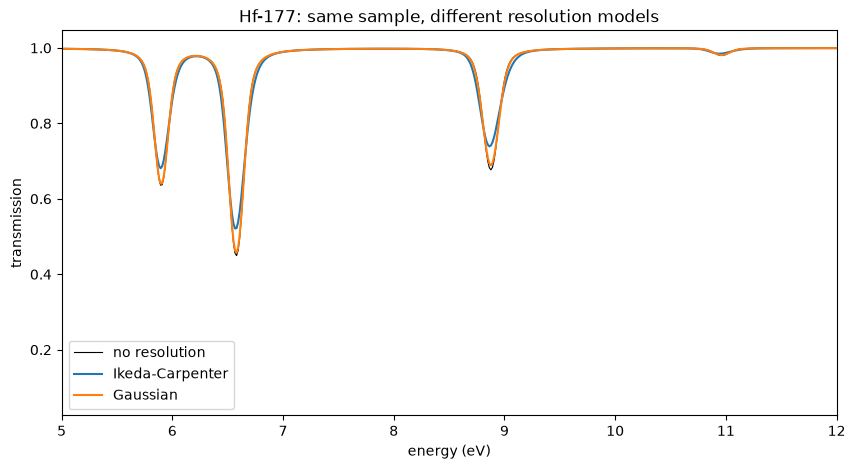

In [2]:
# Ikeda-Carpenter analytic moderator model
ic = nereids.IkedaCarpenter(
    flight_path_m=FLIGHT_PATH_M, e_min_ev=0.5e-3, e_max_ev=1000.0,
    alpha=nereids.EnergyLaw.sqrt_e(0.30, 0.0),   # alpha(E) = 0.30 * sqrt(E)
    beta=0.10,
    r=nereids.EnergyLaw.exp_mev(25.0),           # storage fraction -> 0 in the eV regime
)
ic_kernel = ic.as_tabulated()        # a TabulatedResolution

rho = 5e-5
T_none = np.asarray(nereids.forward_model(energies, [(hf, rho)], temperature_k=300.0))
T_ic   = np.asarray(nereids.forward_model(energies, [(hf, rho)], temperature_k=300.0, resolution=ic_kernel))
T_gau  = np.asarray(nereids.forward_model(energies, [(hf, rho)], temperature_k=300.0,
                                          flight_path_m=FLIGHT_PATH_M, delta_t_us=1.0, delta_l_m=1e-3))

fig, ax = plt.subplots()
ax.plot(energies, T_none, 'k-', lw=0.8, label='no resolution')
ax.plot(energies, T_ic, label='Ikeda-Carpenter')
ax.plot(energies, T_gau, label='Gaussian')
ax.set_xlim(5, 12); ax.set_xlabel('energy (eV)'); ax.set_ylabel('transmission')
ax.set_title('Hf-177: same sample, different resolution models'); ax.legend(); plt.show()

## 2. Calibrate the resolution on a known-(ρ,T) calibrant

We simulate a calibrant whose **true** resolution is the IC kernel, at known density
and temperature, with Poisson noise. `calibrate_resolution` fits each model family's
resolution parameters with ρ and T **fixed**. The calibration χ²/dof tells us which
model the instrument actually obeys: the matched shape fits at χ²≈1, a wrong shape
does not.

In [3]:
# Synthetic calibrant: truth = the IC kernel, known rho,T, non-black (Tmin ~ 0.1)
n_ob = 1e5
counts = rng.poisson(n_ob * np.clip(T_ic, 0, None))
cal_data = counts / n_ob
cal_unc = np.sqrt(np.maximum(counts, 1.0)) / n_ob
print(f"calibrant T_min = {cal_data.min():.3f}  (non-black)")

results = {}
for family, extra in [("ic", {}), ("udd_corr", {"base_udd": ic_kernel}), ("gaussian", {})]:
    cal = nereids.calibrate_resolution(
        energies, cal_data, cal_unc, family,
        isotopes=[(hf, rho)], temperature_k=300.0, restarts=2, **extra,
    )
    results[family] = cal
    print(f"  {family:9s}  chi2/dof = {cal.chi2:6.3f}   params = {cal.params()}")

best = min(results, key=lambda f: results[f].chi2)
print(f"\nbest-fit family (lowest chi2): {best!r}  <- this is the instrument's resolution shape")

calibrant T_min = 0.088  (non-black)


  ic         chi2/dof =  0.986   params = {'a0': 0.30139504162343933, 'a1': 0.00013809915359351744, 'beta': 0.1139148735024093}


  udd_corr   chi2/dof =  0.988   params = {'s0': 0.9945869691608988, 'p': 0.004444824218749999}


  gaussian   chi2/dof =  2.261   params = {'delta_t_us': 2.9290739764575835, 'delta_l_m': 0.0011688354847661662}

best-fit family (lowest chi2): 'ic'  <- this is the instrument's resolution shape


The IC and width-corrected-UDD families fit at χ²≈1 (their shapes match the truth);
the Gaussian cannot reproduce the asymmetric moderator tail and is rejected. The
calibration goodness-of-fit is the evidence for choosing a model.

## 3. Pin the calibrated resolution and fit a sample

Now switch to an unknown sample (different density, warmer) measured on the **same
beamline**. We pin the calibrated resolution and fit density *and* temperature jointly.

In [4]:
# Unknown sample: higher density, warm (truth rho=1.2e-4, T=450 K), lower statistics
T_sample = np.asarray(nereids.forward_model(energies, [(hf, 1.2e-4)], temperature_k=450.0, resolution=ic_kernel))
sc = rng.poisson(2e4 * np.clip(T_sample, 0, None))
samp_data = sc / 2e4
samp_unc = np.sqrt(np.maximum(sc, 1.0)) / 2e4

pinned = results[best].as_tabulated()      # the calibrated resolution
fit = nereids.fit_spectrum_typed(
    samp_data, samp_unc, energies, [(hf, 8e-5)],
    temperature_k=350.0, fit_temperature=True,   # recover rho AND T
    resolution=pinned, max_iter=300,
)
print(f"recovered density     = {float(np.asarray(fit.densities)[0]):.3e}  (truth 1.20e-4)")
print(f"recovered temperature = {fit.temperature_k:.0f} K        (truth 450 K)")
print(f"reduced chi-squared   = {fit.reduced_chi_squared:.2f}")

recovered density     = 1.203e-04  (truth 1.20e-4)
recovered temperature = 447 K        (truth 450 K)
reduced chi-squared   = 1.07


## Takeaways

- **Calibrate on a deep, non-black standard** (T_min ≈ 0.2–0.8) — the calibration χ²
  identifies the instrument's resolution shape directly.
- **Density / isotopic characterization is robust** to the resolution-model choice;
  **temperature is sensitive** — calibrate before trusting a fitted temperature.
- **Pin** the calibrated resolution and re-fit background/normalization per sample;
  the resolution and flight path transfer, the rest do not.

A poor (black-resonance) calibrant soaks self-shielding/scattering into the fitted
"resolution" and will not transfer — choose calibrants whose resonances stay non-black.